In [54]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import postcactus as pc
from postcactus.simdir import SimDir
from postcactus import visualize as viz
from postcactus import grid_data as gd
from postcactus.fourier_util import *

from postcactus import cactus_grid_h5 as cgr
from postcactus import cactus_grid_ascii as cgra

from matplotlib.animation import FuncAnimation
from matplotlib.animation import ArtistAnimation

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import matplotlib as mpl
import matplotlib.colors as colors_lib

In [2]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter

In [3]:
%matplotlib notebook
#%matplotlib inline

In [4]:
rhosat = 1.66e14 * 1.61887093132742e-18
print(5.5*rhosat)
fac_ms = 203.01930744592713
fac_rho = 1.61887093132742e-18
fac_l = 1.4766696910334391

0.0014780291603019345


# Simulation directories

In [90]:
my_sds = [SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.75_HR/output-0013/"),
          SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.5_HR/output-0013/"),
          SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_linear_HR/output-0013/"),
          SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/rates_dU_10_15_tnt_HR/output-0013/")
          ]

In [91]:
Hdf5_list = []
Ascii_list = []
rdr_list = []
itera_list = []
timing_list =[]

for i in range(0,len(my_sds)):
    
    print(i)
    
    Hdf5_list.append(cgr.GridH5Dir(my_sds[i]))
    Ascii_list.append(cgra.GridASCIIDir(my_sds[i]))
    rdr_list.append([Hdf5_list[i], Ascii_list[i]])
    itera_list.append(pc.cactus_grid_omni.GridOmniReader((0,1), rdr_list[i]).get_iters("rho_b"))
    timing_list.append(pc.cactus_grid_omni.GridOmniReader((0,1), rdr_list[i]).get_times("rho_b"))

0
1
2
3


In [92]:
for i in range(0,len(my_sds)):
    print(itera_list[i])

[250752 250880 251008 251136 251264 251392 251520 251648 251776 251904
 252032 252160 252288 252416 252544 252672 252800 252928 253056 253184
 253312 253440 253568 253696 253824 253952 254080 254208 254336 254464
 254592 254720 254848 254976 255104 255232 255360 255488 255616 255744
 255872 256000 256128 256256 256384 256512 256640 256768 256896 257024
 257152 257280 257408 257536 257664 257792 257920 258048 258176 258304
 258432 258560 258688 258816 258944 259072 259200 259328 259456 259584
 259712 259840 259968 260096 260224 260352 260480 260608 260736 260864
 260992 261120 261248 261376 261504 261632 261760 261888 262016 262144
 262272 262400 262528 262656 262784 262912 263040 263168 263296 263424
 263552 263680 263808 263936 264064 264192 264320 264448 264576 264704
 264832 264960 265088 265216 265344 265472 265600 265728 265856 265984
 266112 266240 266368 266496 266624 266752 266880 267008 267136]
[244864 244992 245120 245248 245376 245504 245632 245760 245888 246016
 246144 2462

In [93]:
for i in range(0,len(my_sds)):
    print(timing_list[i])

[8706.66666667 8711.11111111 8715.55555556 8720.         8724.44444444
 8728.88888889 8733.33333333 8737.77777778 8742.22222222 8746.66666667
 8751.11111111 8755.55555556 8760.         8764.44444444 8768.88888889
 8773.33333333 8777.77777778 8782.22222222 8786.66666667 8791.11111111
 8795.55555556 8800.         8804.44444444 8808.88888889 8813.33333333
 8817.77777778 8822.22222222 8826.66666667 8831.11111111 8835.55555556
 8840.         8844.44444444 8848.88888889 8853.33333333 8857.77777778
 8862.22222222 8866.66666667 8871.11111111 8875.55555556 8880.
 8884.44444444 8888.88888889 8893.33333333 8897.77777778 8902.22222222
 8906.66666667 8911.11111111 8915.55555556 8920.         8924.44444444
 8928.88888889 8933.33333333 8937.77777778 8942.22222222 8946.66666667
 8951.11111111 8955.55555556 8960.         8964.44444444 8968.88888889
 8973.33333333 8977.77777778 8982.22222222 8986.66666667 8991.11111111
 8995.55555556 9000.         9004.44444444 9008.88888889 9013.33333333
 9017.77777778

In [94]:
t_merge_dict = {"high_h":4255.555555555556,
                "new_h":4254.444444444444,
                "medium_h":4254.444444444444,
                "zero_h":4252.222222222223}

ind_dict = {"high_h":[0],
            "new_h":[0],
                "medium_h":[0],
                "zero_h":[0]}

NNN = 1

times_dict = {"high_h":[4255.555555555556+23.*fac_ms],
              "new_h":[4254.444444444444+23.*fac_ms],  
              "medium_h":[4254.444444444444+23.*fac_ms],
                "zero_h":[4252.222222222223+23.*fac_ms]}

print(times_dict)

key_list = ["high_h","new_h","medium_h","zero_h"]

for j in range(0,len(my_sds)):
    
    for k in range(0,1):
    
        for i in range(0,len(timing_list[j])):
        
            key = key_list[j]
            time = timing_list[j][i]
        
            if ( time >= times_dict[key][k] ):
                ind_dict[key][k] = itera_list[j][i]
                break
                
print(ind_dict)

{'high_h': [8924.99962681188], 'new_h': [8923.888515700768], 'medium_h': [8923.888515700768], 'zero_h': [8921.666293478545]}
{'high_h': [257152], 'new_h': [257024], 'medium_h': [257024], 'zero_h': [257024]}


In [154]:
for j in range(0,len(my_sds)):
    key = key_list[j]
    for i in range(0,len(timing_list[j])):
        for elem in ind_dict[key]:
            if ( itera_list[j][i] == elem ):
                print((timing_list[j][i]-t_merge_dict[key])/fac_ms)

23.019157104444584
23.002738304798054
23.002738304798054
23.013684171229077


In [96]:
list_of_max_vars = ["rho_b"]
list_of_min_vars = ["alp"]

In [97]:
data_list = []

for j in range(len(my_sds)):
    
    data_dict = {}
    
    for i in range(0,len(list_of_max_vars)):
        
        time_s = my_sds[j].ts.max[list_of_max_vars[i]]
        
        dummy_dict = {list_of_max_vars[i]+"_max" : time_s}
        
        data_dict.update(dummy_dict)
        
    for i in range(0,len(list_of_min_vars)):
        
        time_s = my_sds[j].ts.min[list_of_min_vars[i]]
        
        dummy_dict = {list_of_min_vars[i]+"_min" : time_s}
        
        data_dict.update(dummy_dict)
    
    data_list.append(data_dict)

In [100]:
plotting_styles = ["r-","b-","g-","k-","y-","rx-","gx-","bx-","kx-","yx-","r--","g--","b--","k--","y--"]

<IPython.core.display.Javascript object>


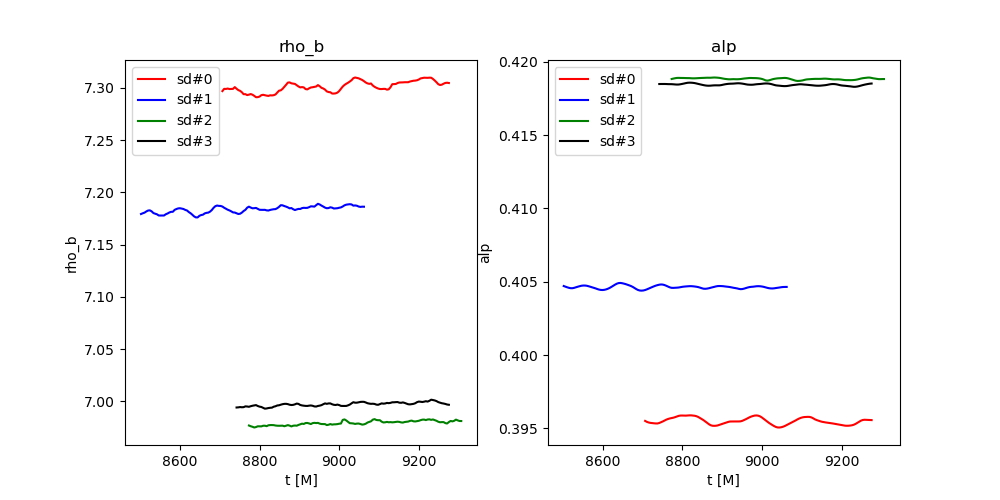

In [101]:
key = "rho_b"

mm = "_max"

key2 = "alp"

mm2 = "_min"

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,5))

for i in range(0,len(my_sds)):
    ax[0].plot(data_list[i][key+mm].t,data_list[i][key+mm].y/rhosat,plotting_styles[i],label="sd#"+str(i))
    
#ax.set_xlim(4.0,8.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax[0].set_ylabel(key)
ax[0].set_xlabel("t [M]")

ax[0].set_title(key)
ax[0].legend()

for i in range(0,len(my_sds)):
    ax[1].plot(data_list[i][key2+mm2].t,data_list[i][key2+mm2].y,plotting_styles[i],label="sd#"+str(i))

#ax.set_xlim(4.0,8.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax[1].set_ylabel(key2)
ax[1].set_xlabel("t [M]")

ax[1].set_title(key2)
ax[1].legend()

# Single plot

In [102]:
string_list = ["rho_b",
               "vel[0]","vel[1]",
               "alp","betax","betay",
               "w_lorentz"]

RHO      = 0
VX       = 1
VY       = 2
LAPSE    = 3
BETAX    = 4
BETAY    = 5
LORY     = 6

In [103]:
# Grid parameters

cells_x1 = 401
cells_x2 = 401

min_x1 = -20
min_x2 = -20
max_x1 = 20
max_x2 = 20

g = gd.RegGeom([cells_x1,cells_x2], [min_x1,min_x2], x1=[max_x1,max_x2])

for j in range(0,len(my_sds)):
    for i in range(0,len(itera_list[j])):
        key = key_list[j]
        for elem in ind_dict[key]:
            if(itera_list[j][i] == elem):
                print("Found!")
        
show_dict = {}

for s in string_list:
    print(s)
    
    data_list = []
    
    for i in range(0,len(my_sds)):
        print(i)
        key = key_list[i]
        data_list_2 = []
        
        for j in range(0,len(ind_dict[key])):
            index = ind_dict[key][j]
            #print(index)
            data_list_2.append(my_sds[i].grid.xy.read(s, index, geom=g, adjust_spacing=0,order=1))
            
        data_list.append(data_list_2)
        
    show_dict.update({s: data_list})

Found!
Found!
Found!
Found!
rho_b
0


/mnt/rafast/chabanov/anaconda3/lib/python3.9/site-packages/scipy/ndimage/interpolation.py:603: UserWarning: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
  warnings.warn(


1
2
3
vel[0]
0
1
2
3
vel[1]
0
1
2
3
alp
0
1
2
3
betax
0
1
2
3
betay
0
1
2
3
w_lorentz
0
1
2
3


In [104]:
#test = my_sds[1].grid.xy.read("vel[1]", 146496, geom=g, adjust_spacing=0,order=1)

In [105]:
mini_x1 = -20
mini_x2 = -20
maxi_x1 = 20
maxi_x2 = 20

In [106]:
coords_x_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
coords_y_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}

coords_r_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
coords_cosphi_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
coords_sinphi_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}

v_phi_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
shift_phi_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
omega_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}

rho_b_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}

for i in range(0,len(my_sds)):
    key = key_list[i]
    for j in range(0,len(ind_dict[key])):
        coords_x_dict[key].append(np.transpose(show_dict["rho_b"][i][j].coords2d()[0]))
        coords_y_dict[key].append(np.transpose(show_dict["rho_b"][i][j].coords2d()[1]))
    
        coords_r_dict[key].append(np.sqrt(pow(coords_x_dict[key][j],2)
                                +pow(coords_y_dict[key][j],2))+1e-17)
        coords_cosphi_dict[key].append(coords_x_dict[key][j]/coords_r_dict[key][j])
        coords_sinphi_dict[key].append(coords_y_dict[key][j]/coords_r_dict[key][j])
              
        rho_b_dict[key].append(np.transpose(show_dict["rho_b"][i][j].data))
    
        shift_phi_dict[key].append(-coords_sinphi_dict[key][j]*np.transpose(show_dict["betax"][i][j].data)/
                              coords_r_dict[key][j]+ \
              np.transpose(show_dict["betay"][i][j].data)*coords_cosphi_dict[key][j]/
                              coords_r_dict[key][j])

        v_phi_dict[key].append(-coords_sinphi_dict[key][j]*np.transpose(show_dict["vel[0]"][i][j].data)/
                          coords_r_dict[key][j] + \
              np.transpose(show_dict["vel[1]"][i][j].data)*coords_cosphi_dict[key][j]/
                          coords_r_dict[key][j])

        omega_dict[key].append(fac_ms * ( np.transpose(show_dict["alp"][i][j].data) * v_phi_dict[key][j] 
                                    - shift_phi_dict[key][j] ) )

In [107]:
for key in omega_dict:
    print(key)
    for elem in omega_dict[key]:
        print(np.amax(elem))

high_h
10.833294971077851
new_h
10.68811201688332
medium_h
10.590250191541365
zero_h
10.474367744322155


In [108]:
minimum = 1.
maximum = 14.

<IPython.core.display.Javascript object>


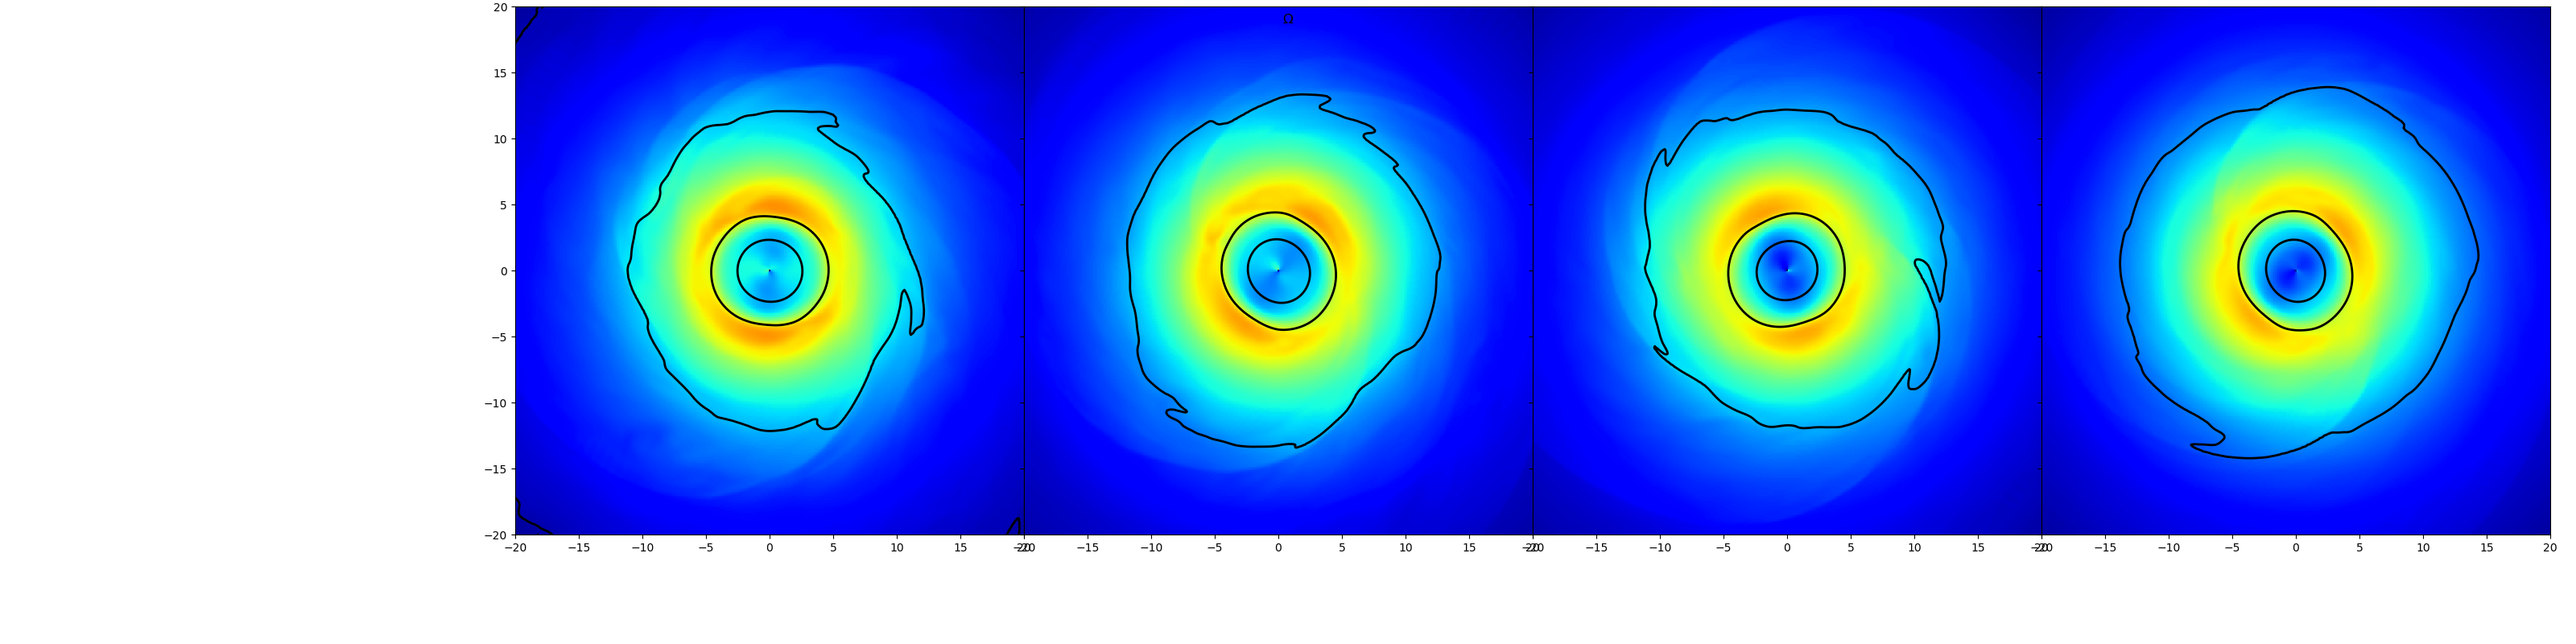

Text(0.5, 0.98, '$\\Omega$')

In [109]:
fig,ax = plt.subplots(1,4,figsize=(32,8),sharex=True,sharey=True)

left  = 0.2    # the left side of the subplots of the figure
right = 0.99    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.99      # the top of the subplots of the figure
wspace = 0.0    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

#RdBu_r
#RdGy_r
#Greys
cm1     = viz.get_color_map("jet");
cm2     = viz.get_color_map("jet");

key = "high_h"

plot_0_0 = ax[0].pcolormesh(coords_x_dict[key][0], coords_y_dict[key][0],omega_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_0 = ax[1,0].pcolormesh(coords_x_dict[key][1], coords_y_dict[key][1],omega_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "new_h"

plot_0_1 = ax[1].pcolormesh(coords_x_dict[key][0], coords_y_dict[key][0],omega_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_1 = ax[1,1].pcolormesh(coords_x_dict[key][1], coords_y_dict[key][1],omega_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "medium_h"

plot_0_2 = ax[2].pcolormesh(coords_x_dict[key][0], coords_y_dict[key][0],omega_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_2 = ax[1,2].pcolormesh(coords_x_dict[key][1], coords_y_dict[key][1],omega_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "zero_h"

plot_0_3 = ax[3].pcolormesh(coords_x_dict[key][0], coords_y_dict[key][0],omega_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_3 = ax[1,3].pcolormesh(coords_x_dict[key][1], coords_y_dict[key][1],omega_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

# Density contours
string_dens1 = 'black'
clrs   = [string_dens1];

key = "high_h"

ax[0].contour(coords_x_dict[key][0], coords_y_dict[key][0],rho_b_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,0].contour(coords_x_dict[key][1], coords_y_dict[key][1],rho_b_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

key = "new_h"

ax[1].contour(coords_x_dict[key][0], coords_y_dict[key][0],rho_b_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,1].contour(coords_x_dict[key][1], coords_y_dict[key][1],rho_b_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

key = "medium_h"

ax[2].contour(coords_x_dict[key][0], coords_y_dict[key][0],rho_b_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,2].contour(coords_x_dict[key][1], coords_y_dict[key][1],rho_b_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

key = "zero_h"

ax[3].contour(coords_x_dict[key][0], coords_y_dict[key][0],rho_b_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,3].contour(coords_x_dict[key][1], coords_y_dict[key][1],rho_b_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);


ax[0].set_xlim(mini_x1,maxi_x1)
ax[0].set_ylim(mini_x2,maxi_x2)

#ax[1,0].set_xlim(mini_x1,maxi_x1)
#ax[1,0].set_ylim(mini_x2,maxi_x2)

ax[1].set_xlim(mini_x1,maxi_x1)
ax[1].set_ylim(mini_x2,maxi_x2)

#ax[1,1].set_xlim(mini_x1,maxi_x1)
#ax[1,1].set_ylim(mini_x2,maxi_x2)

ax[2].set_xlim(mini_x1,maxi_x1)
ax[2].set_ylim(mini_x2,maxi_x2)

#ax[1,2].set_xlim(mini_x1,maxi_x1)
#ax[1,2].set_ylim(mini_x2,maxi_x2)

ax[3].set_xlim(mini_x1,maxi_x1)
ax[3].set_ylim(mini_x2,maxi_x2)

#ax[1,3].set_xlim(mini_x1,maxi_x1)
#ax[1,3].set_ylim(mini_x2,maxi_x2)

#divider_0 = make_axes_locatable(ax[0,0])
#divider_1 = make_axes_locatable(ax[0,1])
#divider_2 = make_axes_locatable(ax[0,2])
#divider_3 = make_axes_locatable(ax[1,2])
#divider_4 = make_axes_locatable(ax[1,1])

#caxx_0 = divider_0.append_axes("right", size="5%", pad=0.2)
#caxx_1 = divider_1.append_axes("right", size="5%", pad=0.2)
#caxx_2 = divider_2.append_axes("right", size="5%", pad=0.2)
#caxx_3 = divider_3.append_axes("right", size="5%", pad=0.2)
#caxx_4 = divider_4.append_axes("right", size="5%", pad=0.2)

#cbar_0 = plt.colorbar(plot_0_a,cax=caxx_0)
#cbar_1 = plt.colorbar(plot_1_a,cax=caxx_1)
#cbar_2 = plt.colorbar(plot_2_a,cax=caxx_2)
#cbar_3 = plt.colorbar(plot_0_b,cax=caxx_3)
#cbar_4 = plt.colorbar(plot_1_b,cax=caxx_4)

#ax[0,0].set_title("high")
#ax[0,1].set_title("med")
#ax[0,2].set_title("low")
#ax[1,2].set_title("zero")
#ax[1,1].set_title("prod")

fig.suptitle("$\\Omega$")

#plt.savefig("omega_2D_new.png", bbox_inches="tight",facecolor='white')

In [110]:
fig.clf()
plt.close("all")

# Average in phi direction

In [111]:
from scipy.interpolate import RegularGridInterpolator

In [131]:
deltar = 0.005
deltaphi = 2.*np.pi/501
startr = 0.001
endr   = np.sqrt(maxi_x1**2+maxi_x2**2)

radius_grid = np.arange(startr,endr,deltar)

phi_grid = np.arange(0.,2.*np.pi,deltaphi)

omega_av_dict = {"high_h":[np.zeros_like(radius_grid)],
                 "new_h":[np.zeros_like(radius_grid)],
                 "medium_h":[np.zeros_like(radius_grid)],
                 "zero_h":[np.zeros_like(radius_grid)]}

rho_b_av_dict = {"high_h":[np.zeros_like(radius_grid)],
                 "new_h":[np.zeros_like(radius_grid)],
                 "medium_h":[np.zeros_like(radius_grid)],
                 "zero_h":[np.zeros_like(radius_grid)]}

rmesh, phimesh = np.meshgrid(radius_grid,phi_grid)

omega_mesh_dict = {"high_h":[np.zeros_like(rmesh)],
                   "new_h":[np.zeros_like(rmesh)],
                 "medium_h":[np.zeros_like(rmesh)],
                 "zero_h":[np.zeros_like(rmesh)]}

rho_b_mesh_dict ={"high_h":[np.zeros_like(rmesh)],
                  "new_h":[np.zeros_like(rmesh)],
                 "medium_h":[np.zeros_like(rmesh)],
                 "zero_h":[np.zeros_like(rmesh)]}

counter_mesh_dict ={"high_h":[np.zeros_like(rmesh)],
                    "new_h":[np.zeros_like(rmesh)],
                 "medium_h":[np.zeros_like(rmesh)],
                 "zero_h":[np.zeros_like(rmesh)]}

# Interpolation dictionairy

omega_interp_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}
rho_b_interp_dict = {"high_h":[],"new_h":[],"medium_h":[],"zero_h":[]}

for i in range(0,len(my_sds)):
    key = key_list[i]
    print(key)
    for j in range(0,len(ind_dict[key])):
        print(j)
        
        omega_interp_dict[key].append(RegularGridInterpolator((coords_x_dict[key][j][0,:]+maxi_x1,coords_y_dict[key][j][:,0]+maxi_x2), 
                                                              omega_dict[key][j], bounds_error=False,fill_value=None))
        
        rho_b_interp_dict[key].append(RegularGridInterpolator((coords_x_dict[key][j][0,:]+maxi_x1,coords_y_dict[key][j][:,0]+maxi_x2), 
                                                              rho_b_dict[key][j], bounds_error=False,fill_value=None))

high_h
0
new_h
0
medium_h
0
zero_h
0


In [132]:
for i in range(0,len(my_sds)):
    key = key_list[i]
    print(key)
    for j in range(0,len(ind_dict[key])):
        print(j)
        
        xmesh = rmesh*np.cos(phimesh) + maxi_x1
        ymesh = rmesh*np.sin(phimesh) + maxi_x2
                
        omega_mesh_dict[key][j] = omega_interp_dict[key][j]((xmesh,ymesh))
                
        rho_b_mesh_dict[key][j] = rho_b_interp_dict[key][j]((xmesh,ymesh))

high_h
0
new_h
0
medium_h
0
zero_h
0


<IPython.core.display.Javascript object>


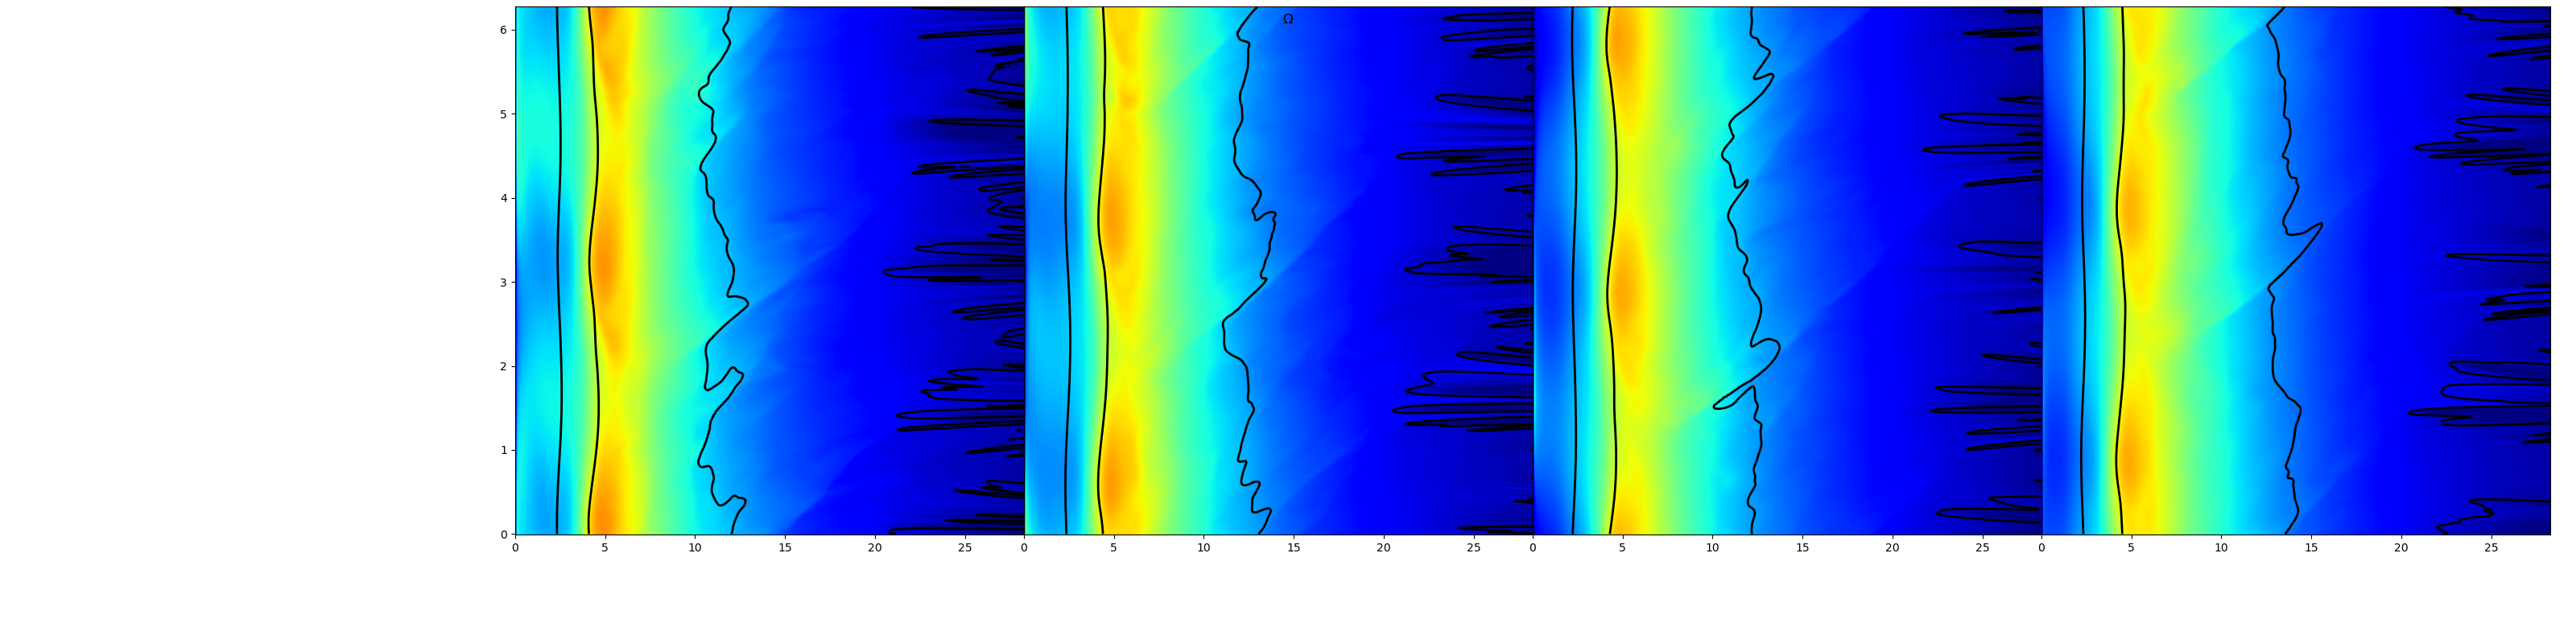

Text(0.5, 0.98, '$\\Omega$')

In [115]:
fig,ax = plt.subplots(1,4,figsize=(32,8),sharex=True,sharey=True)

left  = 0.2    # the left side of the subplots of the figure
right = 0.99    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.99      # the top of the subplots of the figure
wspace = 0.0    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

#RdBu_r
#RdGy_r
#Greys
cm1     = viz.get_color_map("jet");
cm2     = viz.get_color_map("jet");

key = "high_h"

plot_0_0 = ax[0].pcolormesh(rmesh, phimesh, omega_mesh_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_0 = ax[1,0].pcolormesh(rmesh, phimesh, omega_mesh_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "new_h"

plot_0_1 = ax[1].pcolormesh(rmesh, phimesh, omega_mesh_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_1 = ax[1,1].pcolormesh(rmesh, phimesh, omega_mesh_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "medium_h"

plot_0_2 = ax[2].pcolormesh(rmesh, phimesh,omega_mesh_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_2 = ax[1,2].pcolormesh(rmesh, phimesh,omega_mesh_dict[key][1],
#                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

key = "zero_h"

plot_0_2 = ax[3].pcolormesh(rmesh, phimesh,omega_mesh_dict[key][0],
                       norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
                       cmap=cm1)

#plot_1_2 = ax[1,3].pcolormesh(rmesh, phimesh,omega_mesh_dict[key][1],
#                      norm=colors_lib.Normalize(vmin=minimum,vmax=maximum),
#                       cmap=cm1)

# Density contours
string_dens1 = 'black'
clrs   = [string_dens1];

key = "high_h"

ax[0].contour(rmesh, phimesh,rho_b_mesh_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,0].contour(rmesh, phimesh,rho_b_mesh_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

key = "new_h"

ax[1].contour(rmesh, phimesh,rho_b_mesh_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,1].contour(rmesh, phimesh,rho_b_mesh_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);


key = "medium_h"

ax[2].contour(rmesh, phimesh,rho_b_mesh_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,2].contour(rmesh, phimesh,rho_b_mesh_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

key = "zero_h"

ax[3].contour(rmesh, phimesh,rho_b_mesh_dict[key][0],
                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
                         linewidths=2.);

#ax[1,3].contour(rmesh, phimesh,rho_b_mesh_dict[key][1],
#                [0.00073157182561*(1.-0.9999),0.00073157182561*(1.-0.9975),0.00073157182561,1.5e-3], colors=clrs,
#                         linewidths=2.);

fig.suptitle("$\\Omega$")

#plt.savefig("omega_spherical_new.png", bbox_inches="tight",facecolor='white')

In [116]:
fig.clf()
plt.close("all")

In [133]:
for i in range(0,len(my_sds)):
    key = key_list[i]
    print(key)
    for j in range(0,len(ind_dict[key])):
        print(j)
        
        for k in range(0,len(radius_grid)):
                
            omega_av_dict[key][j][k] = np.sum(omega_mesh_dict[key][j][:,k])*deltaphi/2./np.pi
                
            rho_b_av_dict[key][j][k] = np.sum(rho_b_mesh_dict[key][j][:,k])*deltaphi/2./np.pi

high_h
0
new_h
0
medium_h
0
zero_h
0


In [143]:
np.shape(omega_av_dict["high_h"][0])
np.shape(radius_grid)
print(ind_dict["high_h"][0])

257152


In [147]:
# Print to file

"""

file_names_dict = {"high_h":"dU_10_15_pwl_0.75_HR"+"_"+str(ind_dict["high_h"][0])+".txt",
                   "new_h":"dU_10_15_pwl_0.5_HR"+"_"+str(ind_dict["new_h"][0])+".txt",
                   "medium_h":"dU_10_15_linear_HR"+"_"+str(ind_dict["medium_h"][0])+".txt",
                   "zero_h":"rates_dU_10_15_tnt_HR"+"_"+str(ind_dict["zero_h"][0])+".txt"}

np.savetxt('radius.txt', radius_grid)

for elem in omega_av_dict:
    np.savetxt("OMEGA_"+file_names_dict[elem],omega_av_dict[elem][0])
    np.savetxt("RHO_"+file_names_dict[elem],rho_b_av_dict[elem][0])
    
"""

'\n\nfile_names_dict = {"high_h":"dU_10_15_pwl_0.75_HR"+"_"+str(ind_dict["high_h"][0])+".txt",\n                   "new_h":"dU_10_15_pwl_0.5_HR"+"_"+str(ind_dict["new_h"][0])+".txt",\n                   "medium_h":"dU_10_15_linear_HR"+"_"+str(ind_dict["medium_h"][0])+".txt",\n                   "zero_h":"rates_dU_10_15_tnt_HR"+"_"+str(ind_dict["zero_h"][0])+".txt"}\n\nnp.savetxt(\'radius.txt\', radius_grid)\n\nfor elem in omega_av_dict:\n    np.savetxt("OMEGA_"+file_names_dict[elem],omega_av_dict[elem][0])\n    np.savetxt("RHO_"+file_names_dict[elem],rho_b_av_dict[elem][0])\n    \n'

In [148]:
rad = np.loadtxt("./radius.txt")
omega_high = np.loadtxt("./OMEGA_dU_10_15_pwl_0.75_HR_257152.txt")

<IPython.core.display.Javascript object>


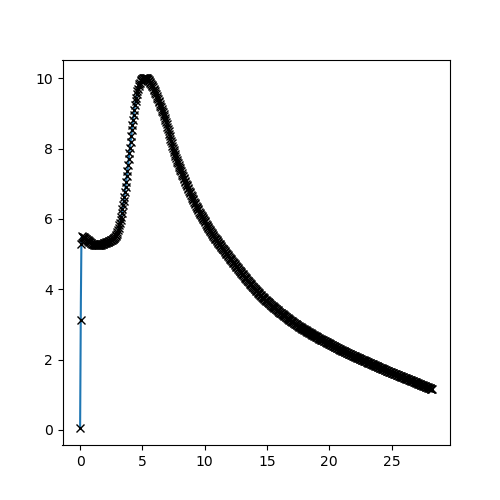

In [153]:
# Check file production

fig,ax = plt.subplots(1,1,figsize=(5,5))

for key in ["high_h"]:
    
    ax.plot(radius_grid,omega_av_dict[key][0])

ax.plot(rad[::10],omega_high[::10],linestyle="",marker="x",color="k")

In [123]:
#f_max_dict= {"high_h":3153.4064026362985,"new_h":3108.3577397419185,"medium_h":3108.3577397414947,"zero_h":3018.2604139518858}

<IPython.core.display.Javascript object>


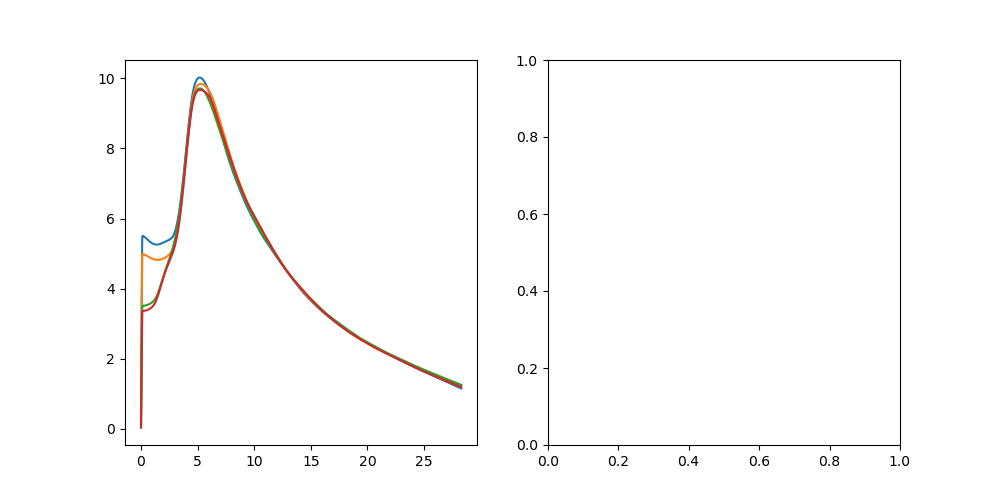

In [140]:
names = ["high_h","new_h","medium_h","zero_h"]

fig,ax = plt.subplots(1,2,figsize=(10,5))

for key in names:
    
    ax[0].plot(radius_grid,omega_av_dict[key][0])
    #ax[1].plot(radius_grid,omega_av_dict[key][1])
    #ax[0].hlines(f_max_dict[key]/1000./2.,min(radius_grid),max(radius_grid))
    #ax[1].hlines(f_max_dict[key]/1000./2.,min(radius_grid),max(radius_grid))
    
#ax[1].set_yscale("log")
#ax[0].set_ylabel("$\\Omega$ [rad kHz]")
#ax[1].set_ylabel("$\\rho$")

#ax[0].legend()

#plt.savefig("omega.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


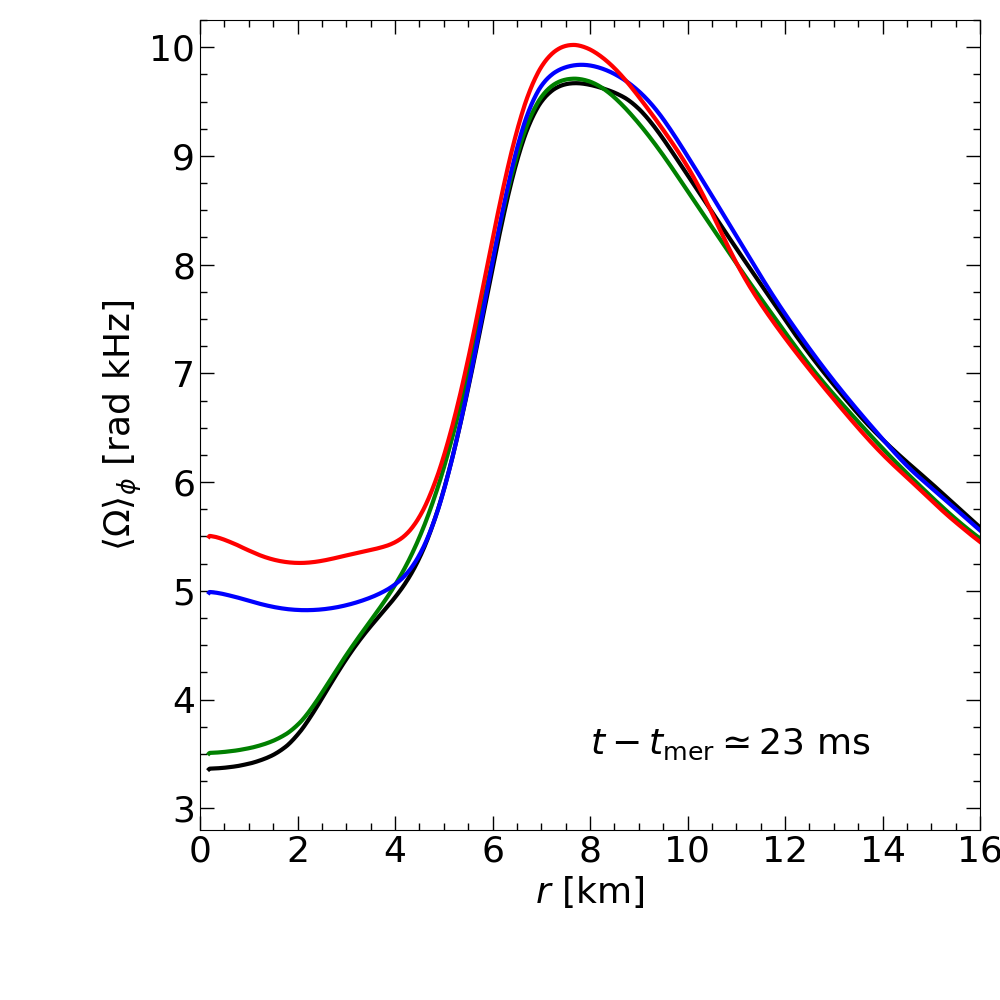

'\nax2 = ax.twinx()\n\nax2.set_ylabel("$ \\left\\langle\\Omega \\right\\rangle_{\\phi} ~[\\mathrm{kHz}]$",fontsize=FONT)\n\nax2.yaxis.set_major_locator(MultipleLocator(0.2))\nax2.yaxis.set_minor_locator(AutoMinorLocator(4))\nax2.set_ylim(3/np.pi/2.,10/np.pi/2.)\n\nax2.tick_params(which=\'major\', width=1.0, labelsize=FONT, direction=\'in\', top=True, right=True)\nax2.tick_params(which=\'major\', length=10, labelsize=FONT, direction=\'in\', top=True, right=True)\nax2.tick_params(which=\'minor\', width=1.0, direction=\'in\', top=True, right=True)\nax2.tick_params(which=\'minor\', length=5,  direction=\'in\', top=True, right=True)\n'

In [120]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

#left  = 0.2    # the left side of the subplots of the figure
#right = 0.8    # the right side of the subplots of the figure
#bottom = 0.17   # the bottom of the subplots of the figure
#top = 0.83      # the top of the subplots of the figure
#wspace = 0.0    # the amount of width reserved for blank space between subplots
#hspace = 0.0    # the amount of height reserved for white space between subplots

left  = 0.2    # the left side of the subplots of the figure
right = 0.98    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.98      # the top of the subplots of the figure
wspace = 0.0    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})
    
#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["zero_h"][0][ind:]*1000.,color=colors["zero_h"],
#        linestyle="dashed",linewidth=2.5,alpha=0.6,
#        label="$\\mathrm{zero~vis.~at~}\\simeq"+str(4.5)+"~\\mathrm{ms}$")

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["zero_h"][0][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{zero~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["medium_h"][0][ind:]*1000.,color=colors["medium_h"],
#        linestyle="dashed",linewidth=2.5,alpha=0.6)

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["medium_h"][0][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["new_h"][0][ind:]*1000.,color=colors["new_h"],
#        linestyle="dashed",linewidth=2.5,alpha=0.6)

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["new_h"][0][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{med.~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["high_h"][0][ind:]*1000.,color=colors["high_h"],
#        linestyle="dashed",linewidth=2.5,alpha=0.6)

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["high_h"][0][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~visc.}$")
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\Omega \\right\\rangle_{\phi} ~[\\mathrm{rad}~\mathrm{kHz}]$",fontsize=FONT)

#ax.legend( prop={'size': FONT}, frameon=True, framealpha=0., edgecolor='white')

#ax.set_title("$t-t_{\\mathrm{mer}}\\simeq"+str(23)+"~\\mathrm{ms}$",fontsize=FONT,pad=10)

ax.text(8.,3.5,"$t-t_{\\mathrm{mer}}\\simeq"+str(23)+"~\\mathrm{ms}$",fontsize=FONT)

ax.set_xlim(0.0,16)
ax.set_ylim(2.8,10.25)

"""
ax2 = ax.twinx()

ax2.set_ylabel("$ \\left\\langle\\Omega \\right\\rangle_{\phi} ~[\mathrm{kHz}]$",fontsize=FONT)

ax2.yaxis.set_major_locator(MultipleLocator(0.2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.set_ylim(3/np.pi/2.,10/np.pi/2.)

ax2.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax2.tick_params(which='minor', length=5,  direction='in', top=True, right=True)
"""

#plt.savefig("./omega_profiles_new.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


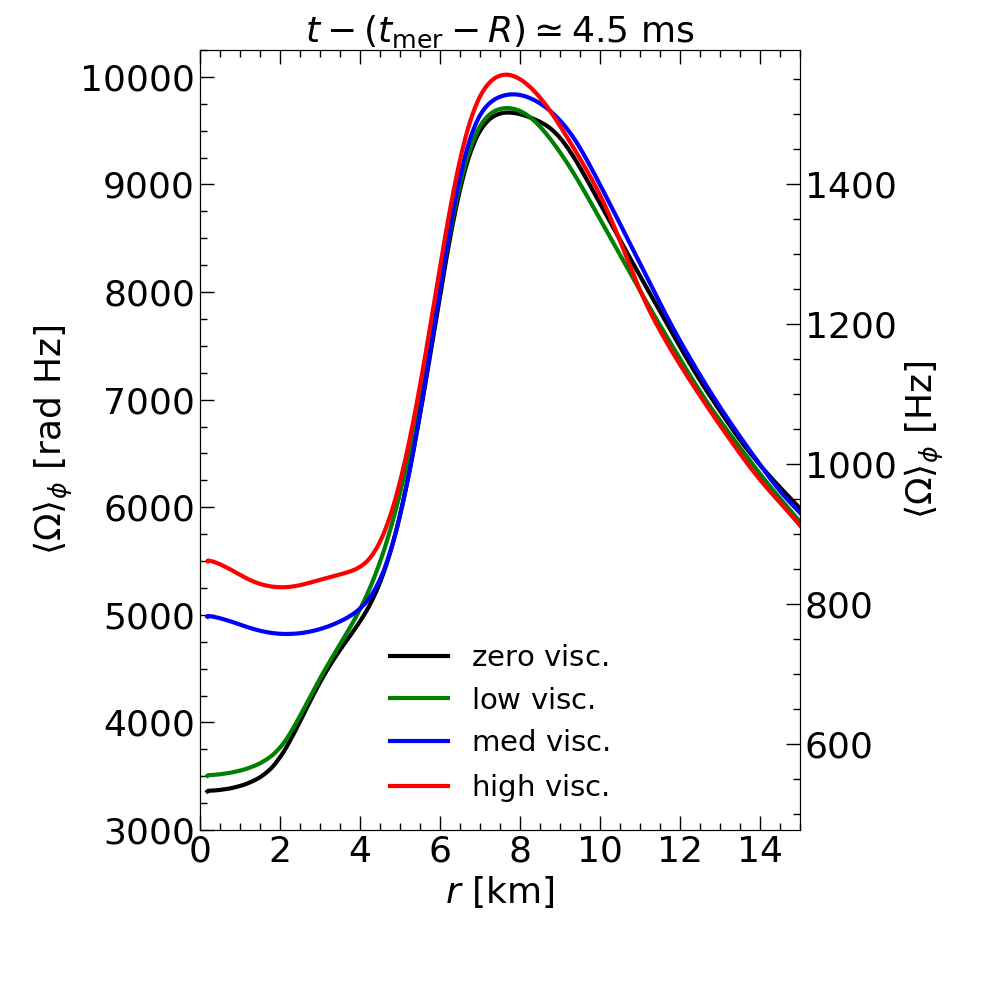

In [121]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

left  = 0.2    # the left side of the subplots of the figure
right = 0.8    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})
    
ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["zero_h"][0][ind:]*1000.,color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["zero_h"][1][ind:]*1000.,color=colors["zero_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{zero~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["medium_h"][0][ind:]*1000.,color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["medium_h"][1][ind:]*1000.,color=colors["medium_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["new_h"][0][ind:]*1000.,color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{med~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["new_h"][1][ind:]*1000.,color=colors["new_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{medium~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["high_h"][0][ind:]*1000.,color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,omega_av_dict["high_h"][1][ind:]*1000.,color=colors["high_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~vis.}$")
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(1000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\Omega \\right\\rangle_{\phi} ~[\\mathrm{rad}~\mathrm{Hz}]$",fontsize=FONT)

ax.legend( prop={'size': FONT-5}, frameon=True, framealpha=0., edgecolor='white',loc="lower center")

ax.set_title("$t-(t_{\\mathrm{mer}}-R)\\simeq"+str(4.5)+"~\\mathrm{ms}$",fontsize=FONT)

ax.set_xlim(0.0,15)
ax.set_ylim(3000,10250)

ax2 = ax.twinx()

ax2.set_ylabel("$ \\left\\langle\\Omega \\right\\rangle_{\phi} ~[\mathrm{Hz}]$",fontsize=FONT)

ax2.yaxis.set_major_locator(MultipleLocator(200))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.set_ylim(3000/np.pi/2.,10000/np.pi/2.)

ax2.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax2.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

#plt.savefig("./omega_profiles_0.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


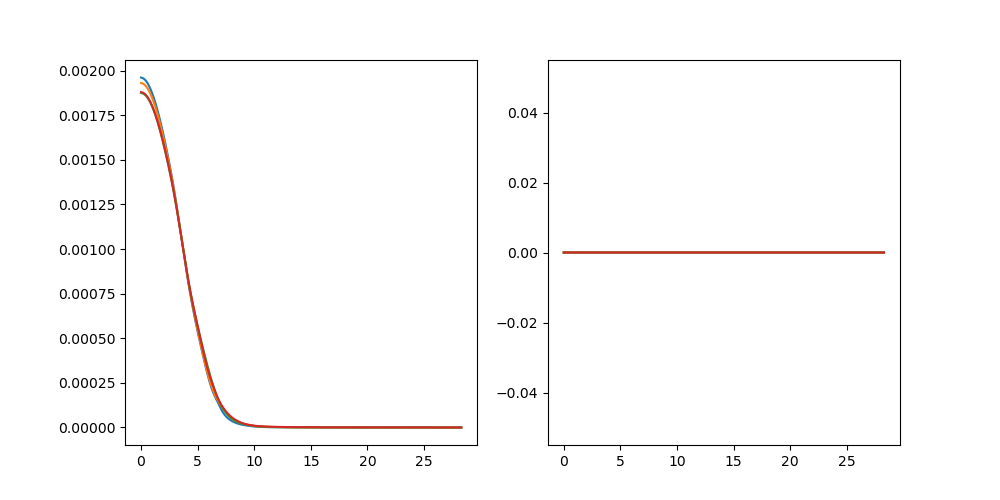

In [75]:
names = ["high_h","new_h","medium_h","zero_h"]

fig,ax = plt.subplots(1,2,figsize=(10,5))

for key in names:
    
    ax[0].plot(radius_grid,rho_b_av_dict[key][0])
    ax[1].plot(radius_grid,rho_b_av_dict[key][1])
    #ax[2].plot(radius_grid,rho_b_av_dict[key][2])
    
#ax[1].set_yscale("log")
#ax[0].set_ylabel("$\\Omega$ [rad kHz]")
#ax[1].set_ylabel("$\\rho$")

#ax[0].legend()

#plt.savefig("omega.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


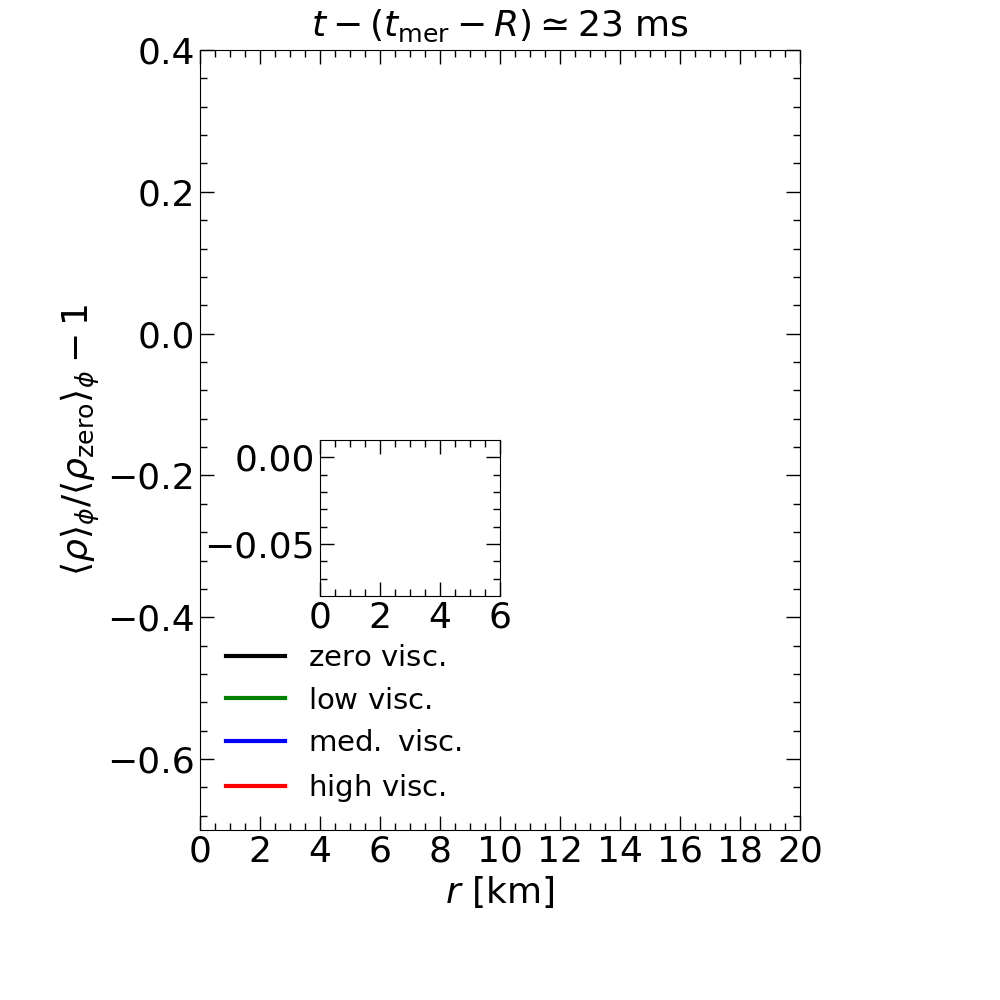

/tmp/ipykernel_701033/2691778371.py:24: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/2691778371.py:32: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/2691778371.py:39: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/2691778371.py:46: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/2691778371.py:76: RuntimeWarning: invalid value encountered in true_divide
  axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:]

(-0.08, 0.01)

In [77]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

left  = 0.2    # the left side of the subplots of the figure
right = 0.8    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})

#ax.hlines(0,25,0.,linestyle="dashed",linewidth=2.,alpha=0.75,color="black")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][1][ind:]/fac_rho/1e15,color=colors["zero_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,
#        label="$\\mathrm{zero~vis.~at~}\\simeq"+str(23)+"~\\mathrm{ms}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][1][ind:]/fac_rho/1e15,color=colors["medium_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{med.~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][1][ind:]/fac_rho/1e15,color=colors["new_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{medium~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][1][ind:]/fac_rho/1e15,color=colors["high_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~vis.}$")
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\rho \\right\\rangle_{\phi}/\\left\\langle\\rho_{\mathrm{zero}} \\right\\rangle_{\phi}-1 $",fontsize=FONT)

ax.legend( prop={'size': FONT-5}, frameon=True, framealpha=0.75, edgecolor='white',loc="lower left")

ax.set_title("$t-(t_{\\mathrm{mer}}-R)\\simeq"+str(23)+"~\\mathrm{ms}$",fontsize=FONT,pad=10)

ax.set_xlim(0.0,20)
#ax.set_yscale("log")
ax.set_ylim(-7.e-1,4.e-1)

axin = ax.inset_axes([0.2, 0.3, 0.3, 0.2])

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{medium~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~vis.}$")
    
axin.xaxis.set_major_locator(MultipleLocator(2))
axin.xaxis.set_minor_locator(AutoMinorLocator(4))
axin.yaxis.set_major_locator(MultipleLocator(0.05))
axin.yaxis.set_minor_locator(AutoMinorLocator(5))

axin.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin.set_xlim(0.,6.)
axin.set_ylim(-0.08,0.01)

#plt.savefig("./rho_b_late_difference.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


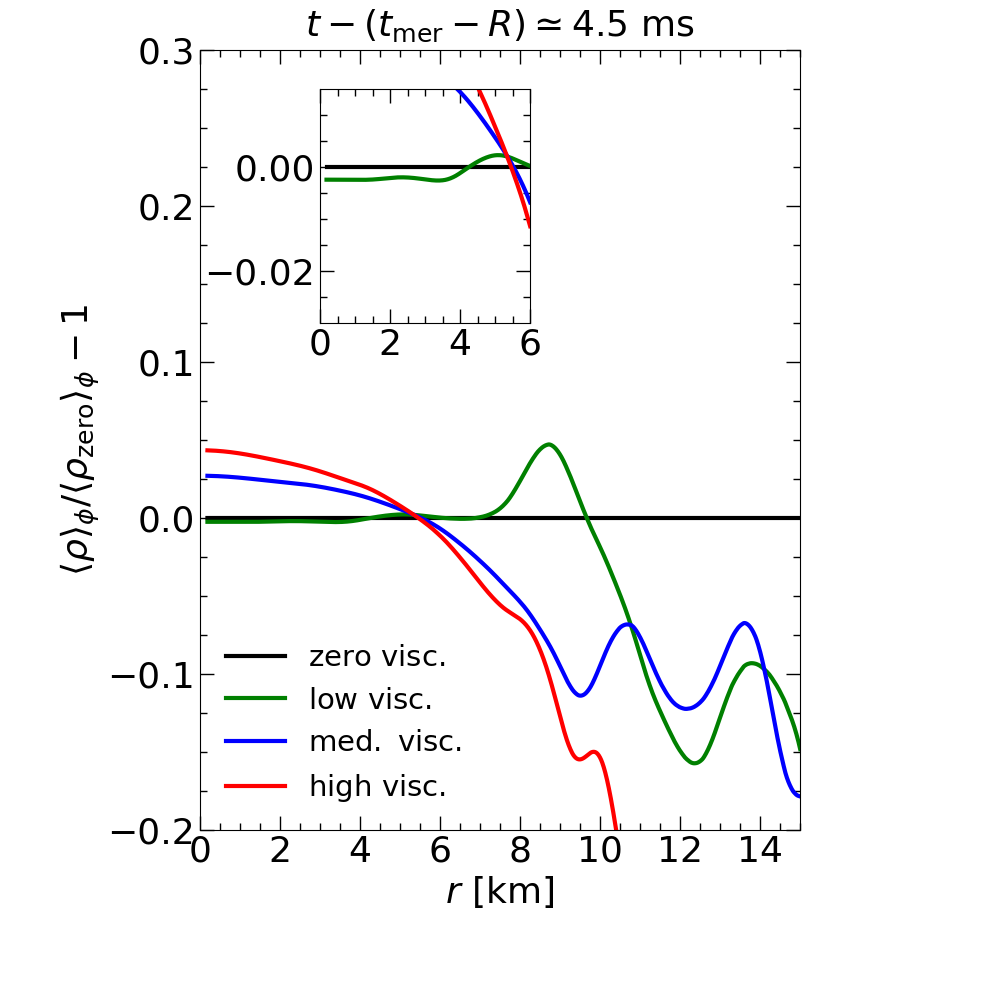

(-0.03, 0.015)

In [82]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

left  = 0.2    # the left side of the subplots of the figure
right = 0.8    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})

#ax.hlines(0,25,0.,linestyle="dashed",linewidth=2.,alpha=0.75,color="black")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][1][ind:]/fac_rho/1e15,color=colors["zero_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,
#        label="$\\mathrm{zero~vis.~at~}\\simeq"+str(23)+"~\\mathrm{ms}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][1][ind:]/fac_rho/1e15,color=colors["medium_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{med.~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][1][ind:]/fac_rho/1e15,color=colors["new_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{medium~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][1][ind:]/fac_rho/1e15,color=colors["high_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~vis.}$")
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\rho \\right\\rangle_{\phi}/\\left\\langle\\rho_{\mathrm{zero}} \\right\\rangle_{\phi}-1 $",fontsize=FONT)

ax.legend( prop={'size': FONT-5}, frameon=True, framealpha=0.75, edgecolor='white',loc="lower left")

ax.set_title("$t-(t_{\\mathrm{mer}}-R)\\simeq"+str(4.5)+"~\\mathrm{ms}$",fontsize=FONT,pad=10)

ax.set_xlim(0.0,15)
#ax.set_yscale("log")
ax.set_ylim(-2.e-1,3.e-1)

axin = ax.inset_axes([0.2, 0.65, 0.35, 0.3])

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{medium~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~vis.}$")
    
axin.xaxis.set_major_locator(MultipleLocator(2))
axin.xaxis.set_minor_locator(AutoMinorLocator(4))
axin.yaxis.set_major_locator(MultipleLocator(0.02))
axin.yaxis.set_minor_locator(AutoMinorLocator(4))

axin.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin.set_xlim(0.,6.)
axin.set_ylim(-0.03,0.015)

#plt.savefig("./rho_b_early_difference.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


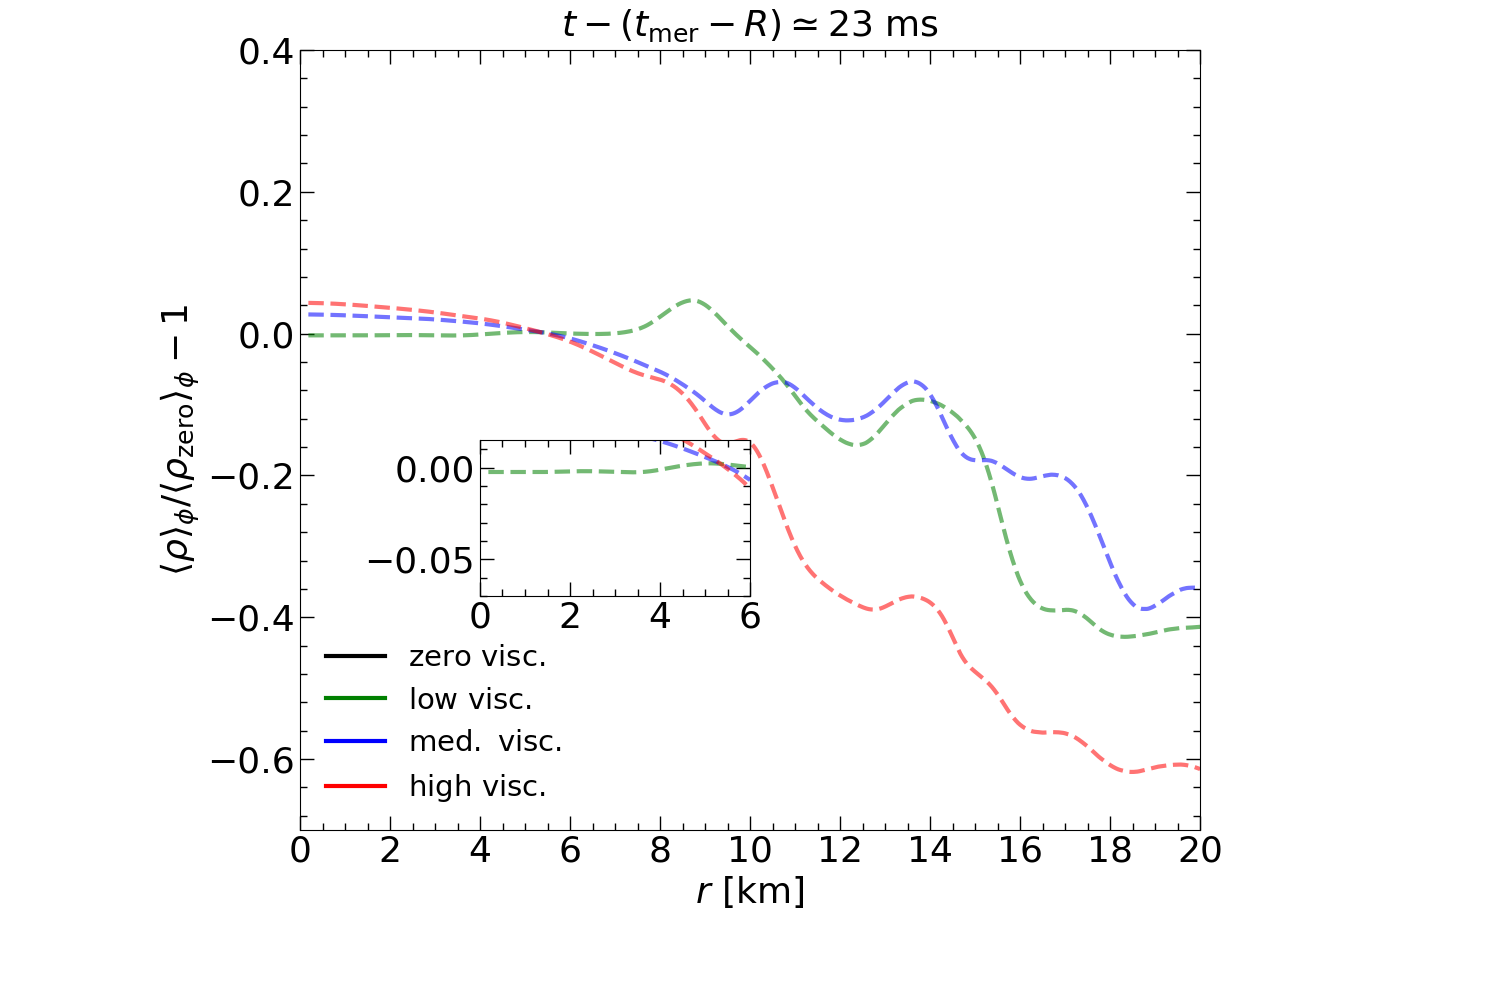

/tmp/ipykernel_701033/279315985.py:22: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/279315985.py:26: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/279315985.py:30: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/279315985.py:34: RuntimeWarning: invalid value encountered in true_divide
  ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/tmp/ipykernel_701033/279315985.py:73: RuntimeWarning: invalid value encountered in true_divide
  axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
/t

(-0.07, 0.015)

In [83]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(15,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

left  = 0.2    # the left side of the subplots of the figure
right = 0.8    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~visc.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~visc.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{med.~visc.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~visc.}$")

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["medium_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["new_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)

ax.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["high_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\rho \\right\\rangle_{\phi}/\\left\\langle\\rho_{\mathrm{zero}} \\right\\rangle_{\phi}-1 $",fontsize=FONT)

ax.legend( prop={'size': FONT-5}, frameon=True, framealpha=0.75, edgecolor='white',loc="lower left")

ax.set_title("$t-(t_{\\mathrm{mer}}-R)\\simeq"+str(23)+"~\\mathrm{ms}$",fontsize=FONT,pad=10)

ax.set_xlim(0.0,20)
#ax.set_yscale("log")
ax.set_ylim(-7.e-1,4.e-1)

axin = ax.inset_axes([0.2, 0.3, 0.3, 0.2])

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["zero_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{medium~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][1][ind:]-rho_b_av_dict["zero_h"][1][ind:])/
        rho_b_av_dict["zero_h"][1][ind:],color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["medium_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["medium_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["new_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["new_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)

axin.plot(radius_grid[ind:]*fac_l,(rho_b_av_dict["high_h"][0][ind:]-rho_b_av_dict["zero_h"][0][ind:])/
        rho_b_av_dict["zero_h"][0][ind:],color=colors["high_h"],
        linestyle="dashed",linewidth=3.,alpha=0.55)
    
axin.xaxis.set_major_locator(MultipleLocator(2))
axin.xaxis.set_minor_locator(AutoMinorLocator(4))
axin.yaxis.set_major_locator(MultipleLocator(0.05))
axin.yaxis.set_minor_locator(AutoMinorLocator(5))

axin.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin.set_xlim(0.,6.)
axin.set_ylim(-0.07,0.015)

#plt.savefig("./rho_b.pdf",bbox_inches="tight")

<IPython.core.display.Javascript object>


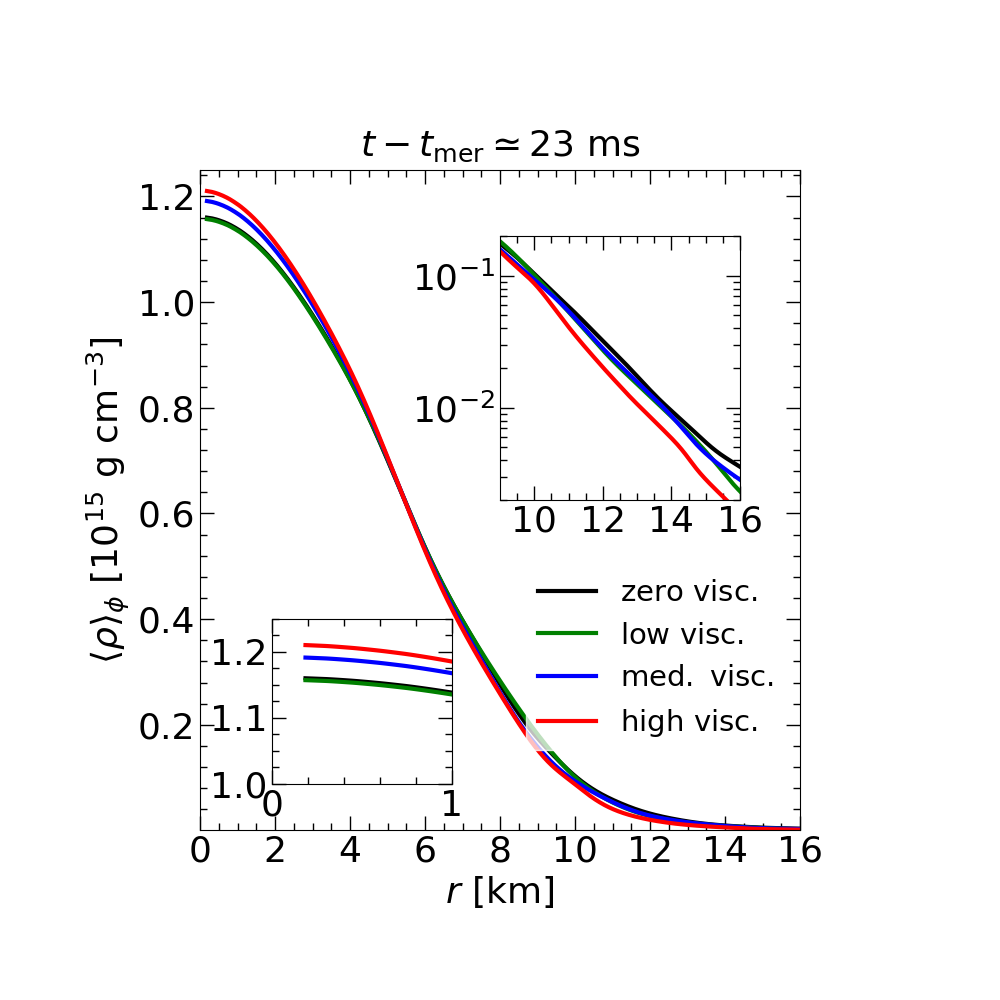

In [89]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

colors = {"high_h":"red","new_h":"blue","medium_h":"green","zero_h":"black"}

left  = 0.2    # the left side of the subplots of the figure
right = 0.8    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.83      # the top of the subplots of the figure
wspace = 0.0    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 25

FONT = 26

plt.rcParams.update({
    "text.usetex": False,
})
    
ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][0][ind:]/fac_rho/1e15,color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][1][ind:]/fac_rho/1e15,color=colors["zero_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,
#        label="$\\mathrm{zero~vis.~at~}\\simeq"+str(23)+"~\\mathrm{ms}$")

ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][0][ind:]/fac_rho/1e15,color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][0][ind:]/fac_rho/1e15,color=colors["medium_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{low~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][0][ind:]/fac_rho/1e15,color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{med.~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][1][ind:]/fac_rho/1e15,color=colors["new_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{medium~vis.}$")

ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][0][ind:]/fac_rho/1e15,color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~visc.}$")

#ax.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][1][ind:]/fac_rho/1e15,color=colors["high_h"],
#        linestyle="solid",linewidth=3.,alpha=1.,label="$\\mathrm{high~vis.}$")
    
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$r \\ [\\mathrm{km}]$",fontsize=FONT)
ax.set_ylabel("$ \\left\\langle\\rho \\right\\rangle_{\phi} ~[10^{15}~\\mathrm{g}~\mathrm{cm}^{-3}]$",fontsize=FONT)

ax.legend( prop={'size': FONT-5}, frameon=True, framealpha=0.75, edgecolor='white',
         loc='best', bbox_to_anchor=(0.5, 0., 0.5, 0.42))

ax.set_title("$t-t_{\\mathrm{mer}}\\simeq"+str(23)+"~\\mathrm{ms}$",fontsize=FONT,pad=10)

ax.set_xlim(0.0,16)
#ax.set_yscale("log")
ax.set_ylim(1e-3,1.25)

axin = ax.inset_axes([0.12, 0.07, 0.3, 0.25])

axin.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][0][ind:]/fac_rho/1e15,color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][0][ind:]/fac_rho/1e15,color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][0][ind:]/fac_rho/1e15,color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{medium~vis.}$")

axin.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][0][ind:]/fac_rho/1e15,color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~vis.}$")
    
axin.xaxis.set_major_locator(MultipleLocator(1.0))
axin.xaxis.set_minor_locator(AutoMinorLocator(5))
axin.yaxis.set_major_locator(MultipleLocator(0.1))
axin.yaxis.set_minor_locator(AutoMinorLocator(4))

axin.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin.set_xlim(0.,1.)
axin.set_ylim(1.,1.25)

axin2 = ax.inset_axes([0.5, 0.5, 0.4, 0.4])

axin2.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["zero_h"][0][ind:]/fac_rho/1e15,color=colors["zero_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{zero~vis.}$")

axin2.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["medium_h"][0][ind:]/fac_rho/1e15,color=colors["medium_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{low~vis.}$")

axin2.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["new_h"][0][ind:]/fac_rho/1e15,color=colors["new_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{medium~vis.}$")

axin2.plot(radius_grid[ind:]*fac_l,rho_b_av_dict["high_h"][0][ind:]/fac_rho/1e15,color=colors["high_h"],
        linestyle="solid",linewidth=3.,alpha=1.0,label="$\\mathrm{high~vis.}$")
    
axin2.xaxis.set_major_locator(MultipleLocator(2.0))
axin2.xaxis.set_minor_locator(AutoMinorLocator(4))
#axin2.yaxis.set_major_locator(MultipleLocator(0.1))
#axin2.yaxis.set_minor_locator(AutoMinorLocator(4))

axin2.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
axin2.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
axin2.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin2.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin2.set_xlim(9.,16.)
axin2.set_ylim(2e-3,0.2)
axin2.set_yscale("log")

#plt.savefig("./rho_b_profiles.pdf",bbox_inches="tight")